![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

Zmienna losowa 𝑋 ma w przedziale $[0,1]$ ma gęstość rozkładu prawdopodobieństwa $f(x)=\frac{3}{4}(x^2+2x)$ i zero poza nim.

In [1]:
from scipy import stats as st # import podstawowej biblioteki z obiektami rozkładów prawdopodobieństwa
import numpy as np # wymagane do manipulacji tablicami numpy
import matplotlib.pyplot as plt #biblioteki wymagane do wykresu

In [2]:
class rozklad(st.rv_continuous): # dziedziczenie po klasie rv_continuous
    "rozkład z zadania 5"
    def _pdf(self, x:float)->float: # przeciążenie funkcji _pdf (gęstość prawdopodobieństwa)
        return  np.piecewise(x, [(x >= 0)*(x <= 1), (x<0)+(x>1)], [lambda x:0.75*(x**2.+2.*x), 0.])

    def _cdf(self, x:float)->float: # przeciążenie funkcji _pdf (gęstość prawdopodobieństwa)
        return  np.piecewise(x, [x < 0, (x >= 0)*(x <= 1), x > 1], [0., lambda x:0.75*(x**3./3. + x**2.), 1.])

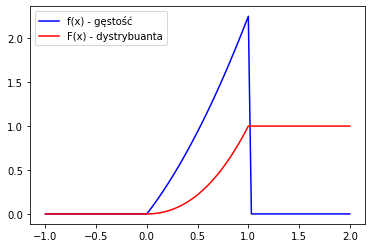

In [3]:
r = rozklad() # utworzenie instancji obiektu rozkładu

x = np.linspace(-1,2,100) # wektor wartości x
f = r.pdf(x) # wektor wartości gęstości rozkładu prawdopodobieństwa
F = r.cdf(x) # obliczenie wartości dystrybuanty

plt.plot(x,f,"blue",x,F,"red")
plt.legend(["f(x) - gęstość","F(x) - dystrybuanta"])
pass

In [4]:
E = r.expect()
V = r.var()
[E,V]

[0.6875, 0.052343750008044865]